# ANN Retrain - Best Hyperparameters
### Anaerobic Digestion of Olive Mill Waste - Crete Case Study

---

## So far:

the K-Fold notebook ran 144 combinations of hyperparameters across 6 folds each and:

**learning rate is by far the most important factor**
every combination with lr=0.0001 ended up near the bottom of the rankings,
with validation losses around 0.78–1.23. that means that the model cannot learn fast enough
at that rate in 100 epochs. lr=0.001 dominated the top of the table

**bigger hidden layers help but not dramatically**
the first training run used H1=15, H2=9 as a rough guess that came out around rank 11.
moving to H1=20, H2=15 gave an improvement. going higher than that (H1=25)
gave little return and sometimes worse performance due to slower convergence
in the fixed 100-epoch window

**smaller batch size consistently beats larger ones**
batch=50 is always in the top 10. batch=200 appears at the bottom.
smaller batches mean more gradient updates per epoch which matters especially
when epochs are limited. with 27,000 training rows and batch=50, the model
sees 540 gradient updates per epoch instead of 135 with batch=200.

**the winning combination:**
- H1=20, H2=15, lr=0.001, batch=50
- avg validation loss: 0.02591

**what changes in this notebook vs the first training run:**
- H1: 15 → 20
- H2: 9 → 15
- batch: 100 → 50
- epochs: 200 → 500
- everything else stays the same


## 1. Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import copy
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

print('torch version:', torch.__version__)
print('cuda available:', torch.cuda.is_available())

torch version: 2.11.0
cuda available: False


## 2. Hyperparameters

defined at the top so they're easy to find and change.
these come directly from the K-Fold search results


In [2]:
# best hyperparameters from K-Fold search 
D_in  = 5      # inputs: S, M, pH, T, OLR
H1    = 20     # hidden layer 1 neurons (15 in first run)
H2    = 15     # hidden layer 2 neurons (9 in first run)
D_out = 3      # outputs: dS/dt, dM/dt, dpH/dt

N             = 50       # batch size (100 in first run)
learning_rate = 1e-3     # same as first run (confirmed best by K-Fold)
train_epochs  = 500      # more epochs (1st run said 'still decreasing' at 200)

print('hyperparameters:')
print(f'  architecture : Net({D_in}, {H1}, {H2}, {D_out})')
print(f'  batch size   : {N}')
print(f'  learning rate: {learning_rate}')
print(f'  epochs       : {train_epochs}')
print()
params = (D_in*H1 + H1) + (H1*H2 + H2) + (H2*D_out + D_out)
print(f'  total parameters: {params}')
print(f'  (first run had {(5*15+15)+(15*9+9)+(9*3+3)} parameters)')

hyperparameters:
  architecture : Net(5, 20, 15, 3)
  batch size   : 50
  learning rate: 0.001
  epochs       : 500

  total parameters: 483
  (first run had 264 parameters)


## 3. Load Data

In [3]:
book = openpyxl.load_workbook('olive_mill_database.xlsx',
                               read_only=True, data_only=True)

# load reference data to fit scaler
sheet_ref = book['STANDARDISATION_REF']
data_ref  = []
for r in sheet_ref.iter_rows(min_row=4, values_only=True):
    data_ref.append([r[c] for c in range(8)])

# load augmented training data
sheet_train = book['PREPARED_TRAINING']
data_train  = []
for r in sheet_train.iter_rows(min_row=4, values_only=True):
    data_train.append([r[c] for c in range(8)])

print(f'reference data : {len(data_ref)} rows')
print(f'training data  : {len(data_train)} rows')

reference data : 1080 rows
training data  : 27000 rows


## 4. Standardise

In [4]:
scaler = StandardScaler()
scaler.fit(data_ref)

standardised = scaler.transform(data_train)

x_train = torch.tensor(standardised[:, 0:5], dtype=torch.float32)
y_train = torch.tensor(standardised[:, 5:8], dtype=torch.float32)

print(f'x_train: {x_train.shape}  (inputs)')
print(f'y_train: {y_train.shape}  (targets)')
print()
print('standardised input ranges:')
for i, name in enumerate(['S', 'M', 'pH', 'T', 'OLR']):
    col = x_train[:, i]
    print(f'  {name}: min={col.min():.2f}  max={col.max():.2f}')

x_train: torch.Size([27000, 5])  (inputs)
y_train: torch.Size([27000, 3])  (targets)

standardised input ranges:
  S: min=-1.30  max=3.19
  M: min=-1.43  max=2.76
  pH: min=-4.35  max=5.02
  T: min=-1.85  max=1.92
  OLR: min=-1.16  max=1.47


## 5. Define Model

In [5]:
class Net(nn.Module):
    def __init__(self, D_in, H1, H2, D_out):
        super(Net, self).__init__()
        self.linear1 = nn.Linear(D_in, H1)
        self.linear2 = nn.Linear(H1, H2)
        self.linear3 = nn.Linear(H2, D_out)

    def forward(self, x):
        x = torch.sigmoid(self.linear1(x))
        x = torch.sigmoid(self.linear2(x))
        x = self.linear3(x)
        return x

model   = Net(D_in, H1, H2, D_out)
loss_fn = nn.MSELoss(reduction='mean')

print('model:')
print(model)
print()
test = model(x_train[:N])
print(f'forward pass OK — output shape: {test.shape}')

model:
Net(
  (linear1): Linear(in_features=5, out_features=20, bias=True)
  (linear2): Linear(in_features=20, out_features=15, bias=True)
  (linear3): Linear(in_features=15, out_features=3, bias=True)
)

forward pass OK — output shape: torch.Size([50, 3])


## 6. DataLoader

In [6]:
dataset    = torch.utils.data.TensorDataset(x_train, y_train)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=N, shuffle=True)

print(f'dataset size    : {len(dataset)}')
print(f'batch size      : {N}')
print(f'batches/epoch   : {len(dataloader)}')
print(f'gradient updates per epoch: {len(dataloader)}  '
      f'(vs {len(dataset)//100} with batch=100 in first run)')

dataset size    : 27000
batch size      : 50
batches/epoch   : 540
gradient updates per epoch: 540  (vs 270 with batch=100 in first run)


## 7. Train

500 epochs this time. printing every 25 epochs.
watch the log-scale plot after ( goal is to see it go fully flat)


In [7]:
optimizer    = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_history = []

model.train()
print(f'training: {train_epochs} epochs, lr={learning_rate}, batch={N}')
print('-' * 60)

for epoch in range(train_epochs):
    epoch_loss = 0.0
    for x_batch, y_batch in dataloader:
        y_pred = model(x_batch)
        loss   = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() / len(dataloader)
    loss_history.append(epoch_loss)
    if epoch % 25 == 0 or epoch == train_epochs - 1:
        print(f'epoch {epoch:>4d}   loss = {epoch_loss:.6f}')

print('-' * 60)
print(f'done. final loss: {loss_history[-1]:.6f}')
print(f'first run final: 0.003667')
print(f'improvement: {((0.003667 - loss_history[-1])/0.003667)*100:.1f}%')

training: 500 epochs, lr=0.001, batch=50
------------------------------------------------------------
epoch    0   loss = 0.592271
epoch   25   loss = 0.004770
epoch   50   loss = 0.004488
epoch   75   loss = 0.004342
epoch  100   loss = 0.004126
epoch  125   loss = 0.003735
epoch  150   loss = 0.003452
epoch  175   loss = 0.003322
epoch  200   loss = 0.003221
epoch  225   loss = 0.003179
epoch  250   loss = 0.003120
epoch  275   loss = 0.002914
epoch  300   loss = 0.002328
epoch  325   loss = 0.001995
epoch  350   loss = 0.001819
epoch  375   loss = 0.001736
epoch  400   loss = 0.001671
epoch  425   loss = 0.001642
epoch  450   loss = 0.001600
epoch  475   loss = 0.001592
epoch  499   loss = 0.001549
------------------------------------------------------------
done. final loss: 0.001549
first run final: 0.003667
improvement: 57.8%


## 8. Loss Curve

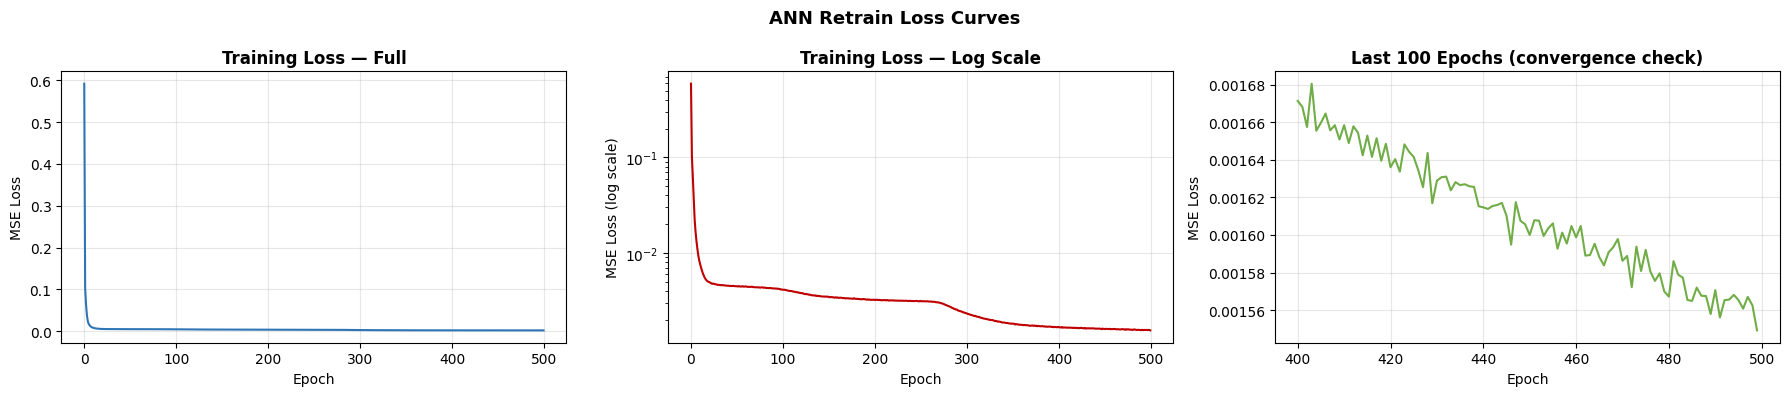

loss drop in last  50 epochs: 0.0000507
loss drop in last 100 epochs: 0.0001220
nearly converged — a few more epochs would help but not critical


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(loss_history, color='#2E75B6', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss — Full', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(loss_history, color='#C00000', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss (log scale)')
axes[1].set_title('Training Loss — Log Scale', fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(range(train_epochs-100, train_epochs),
             loss_history[-100:], color='#70AD47', linewidth=1.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE Loss')
axes[2].set_title('Last 100 Epochs (convergence check)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('ANN Retrain Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

last50_drop  = loss_history[-50]  - loss_history[-1]
last100_drop = loss_history[-100] - loss_history[-1]
print(f'loss drop in last  50 epochs: {last50_drop:.7f}')
print(f'loss drop in last 100 epochs: {last100_drop:.7f}')
if last50_drop < 0.00005:
    print('CONVERGED — training is complete')
elif last50_drop < 0.0002:
    print('nearly converged — a few more epochs would help but not critical')
else:
    print('still decreasing — consider running more epochs')

## 9. Compare to First Training Run

In [9]:
print('comparison summary:')
print(f'{"":30} {"First Run":>12} {"Retrain":>12}')
print('-' * 55)
print(f'{"Architecture":<30} {"Net(5,15,9,3)":>12} {f"Net({D_in},{H1},{H2},{D_out})":>12}')
print(f'{"Parameters":<30} {"264":>12} {str(params):>12}')
print(f'{"Batch size":<30} {"100":>12} {str(N):>12}')
print(f'{"Epochs":<30} {"200":>12} {str(train_epochs):>12}')
print(f'{"Final MSE loss":<30} {"0.003667":>12} {loss_history[-1]:>12.6f}')
print(f'{"Loss reduction":<30} {"99.6%":>12} '
      f'{((loss_history[0]-loss_history[-1])/loss_history[0])*100:>11.1f}%')
print('-' * 55)

comparison summary:
                                  First Run      Retrain
-------------------------------------------------------
Architecture                   Net(5,15,9,3) Net(5,20,15,3)
Parameters                              264          483
Batch size                              100           50
Epochs                                  200          500
Final MSE loss                     0.003667     0.001549
Loss reduction                        99.6%        99.7%
-------------------------------------------------------


## 10. Predicted vs Actual

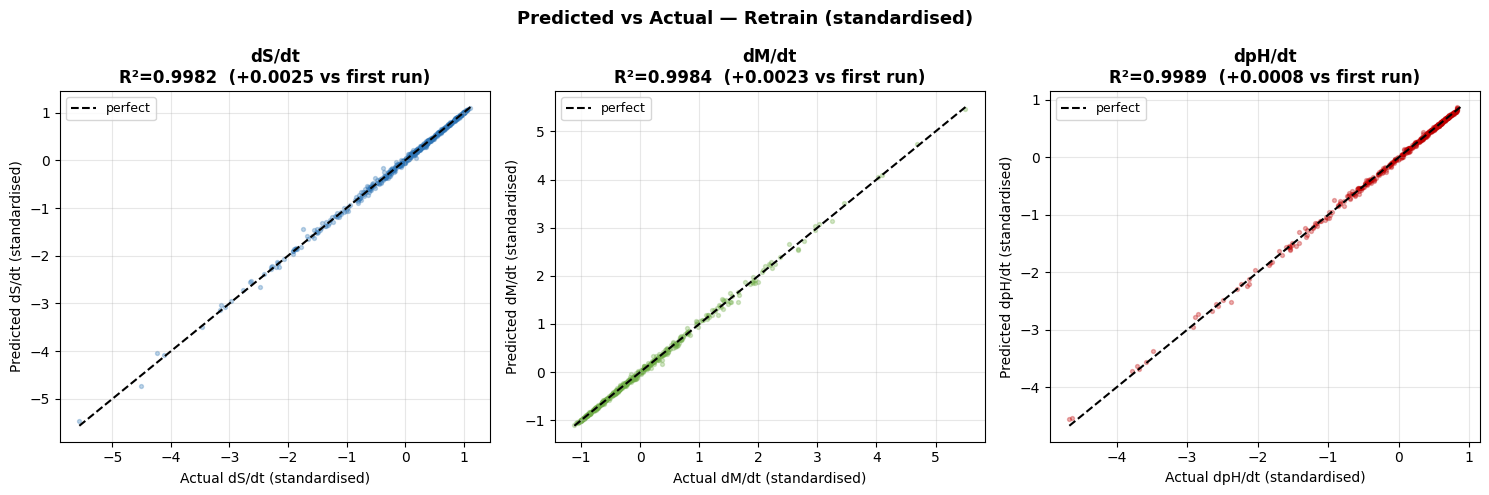

R² comparison:
                First Run      Retrain     Change
-----------------------------------------------
  dS/dt            0.9957       0.9982    +0.0025
  dM/dt            0.9961       0.9984    +0.0023
  dpH/dt           0.9981       0.9989    +0.0008


In [10]:
model.eval()
with torch.no_grad():
    sample_x = x_train[:500]
    sample_y = y_train[:500]
    preds    = model(sample_x)

preds_np  = preds.numpy()
actual_np = sample_y.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
target_names = ['dS/dt', 'dM/dt', 'dpH/dt']
colors = ['#2E75B6', '#70AD47', '#C00000']
first_run_r2 = [0.9957, 0.9961, 0.9981]

for i, (ax, name, col, fr2) in enumerate(
        zip(axes, target_names, colors, first_run_r2)):
    ax.scatter(actual_np[:, i], preds_np[:, i], alpha=0.3, s=8, color=col)
    lims = [min(actual_np[:,i].min(), preds_np[:,i].min()),
            max(actual_np[:,i].max(), preds_np[:,i].max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='perfect')
    ss_res = np.sum((actual_np[:,i] - preds_np[:,i])**2)
    ss_tot = np.sum((actual_np[:,i] - actual_np[:,i].mean())**2)
    r2 = 1 - ss_res/ss_tot
    delta = r2 - fr2
    delta_str = f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}'
    ax.set_xlabel(f'Actual {name} (standardised)')
    ax.set_ylabel(f'Predicted {name} (standardised)')
    ax.set_title(f'{name}\nR²={r2:.4f}  ({delta_str} vs first run)',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs Actual — Retrain (standardised)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('R² comparison:')
print(f'{"":12} {"First Run":>12} {"Retrain":>12} {"Change":>10}')
print('-' * 47)
for i, name in enumerate(target_names):
    ss_res = np.sum((actual_np[:,i] - preds_np[:,i])**2)
    ss_tot = np.sum((actual_np[:,i] - actual_np[:,i].mean())**2)
    r2 = 1 - ss_res/ss_tot
    delta = r2 - first_run_r2[i]
    delta_str = f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}'
    print(f'  {name:<10} {first_run_r2[i]:>12.4f} {r2:>12.4f} {delta_str:>10}')

## 11. Residual Analysis

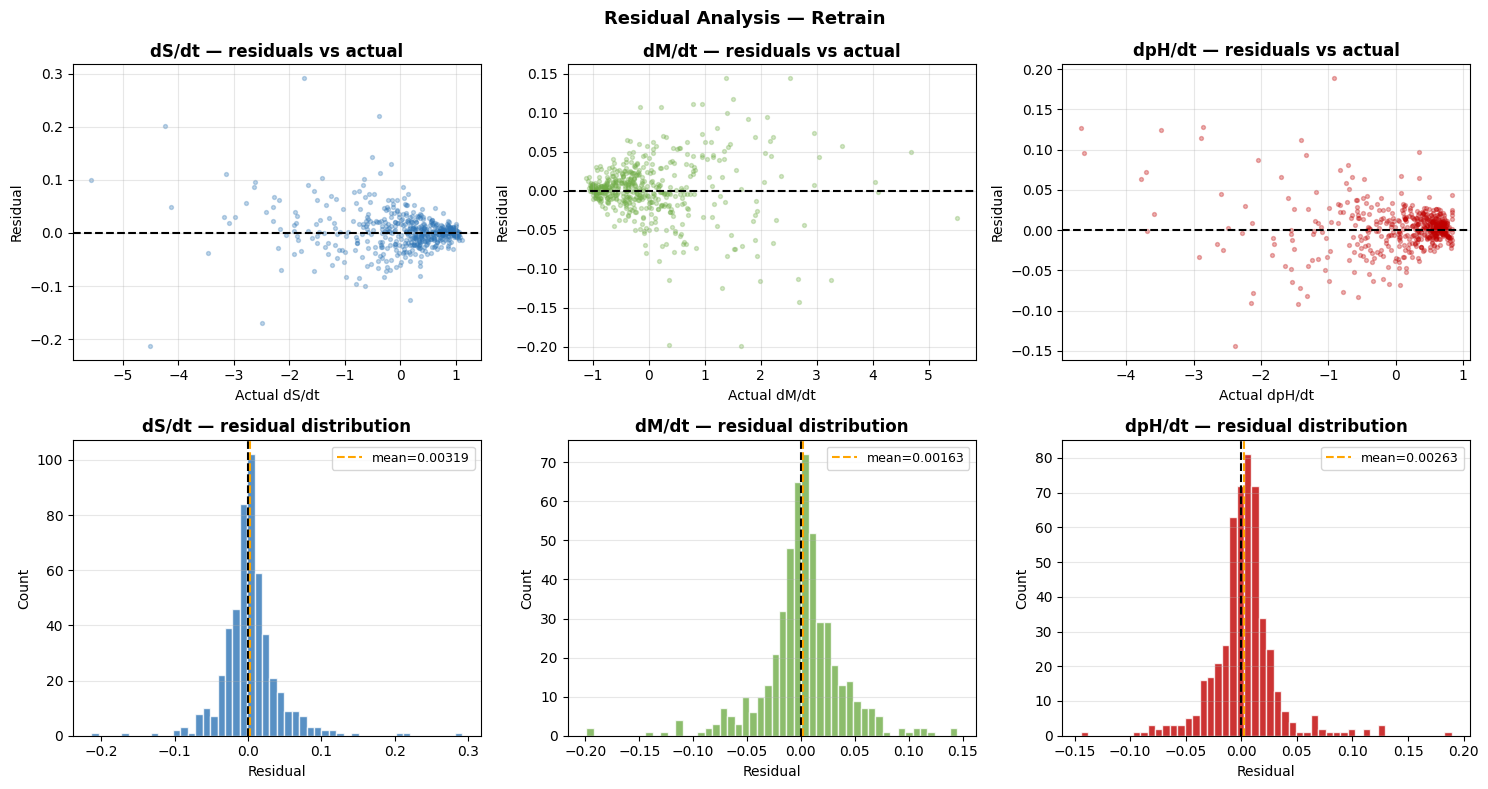

residual means (should be ~0):
  dS/dt: 0.003187
  dM/dt: 0.001630
  dpH/dt: 0.002627


In [11]:
residuals = preds_np - actual_np
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (name, col) in enumerate(zip(target_names, colors)):
    axes[0, i].scatter(actual_np[:, i], residuals[:, i],
                       alpha=0.3, s=8, color=col)
    axes[0, i].axhline(0, color='black', linewidth=1.5, linestyle='--')
    axes[0, i].set_xlabel(f'Actual {name}')
    axes[0, i].set_ylabel('Residual')
    axes[0, i].set_title(f'{name} — residuals vs actual', fontweight='bold')
    axes[0, i].grid(True, alpha=0.3)

    axes[1, i].hist(residuals[:, i], bins=50, color=col,
                    alpha=0.8, edgecolor='white')
    axes[1, i].axvline(0, color='black', linewidth=1.5, linestyle='--')
    axes[1, i].axvline(residuals[:, i].mean(), color='orange',
                       linewidth=1.5, linestyle='--',
                       label=f'mean={residuals[:,i].mean():.5f}')
    axes[1, i].set_xlabel('Residual')
    axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'{name} — residual distribution', fontweight='bold')
    axes[1, i].legend(fontsize=9)
    axes[1, i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Residual Analysis — Retrain', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('residual means (should be ~0):')
for i, name in enumerate(target_names):
    print(f'  {name}: {residuals[:,i].mean():.6f}')

## 12. Physical Units Check

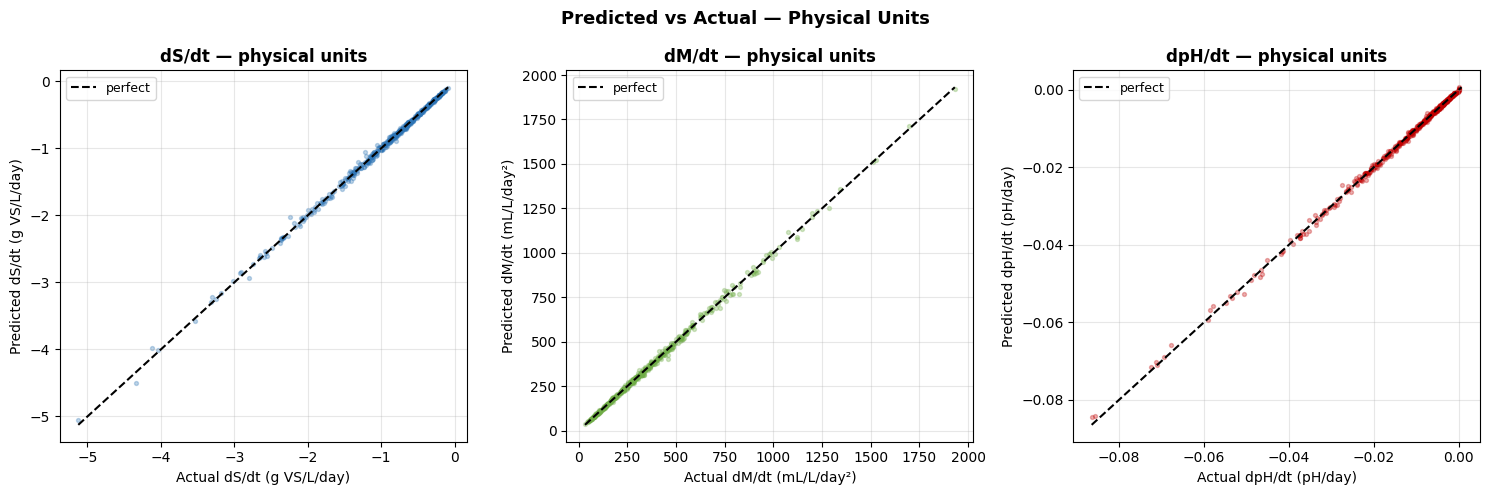

prediction ranges vs physical limits:
  dS/dt: [-5.0500, -0.0973]  limit [-5.5, 0.0]  violations: 0
  dM/dt: [37.4534, 1921.3771]  limit [0.0, 2000.0]  violations: 0
  dpH/dt: [-0.0845, 0.0007]  limit [-0.09, 0.0]  violations: 6


In [12]:
actual_full = np.zeros((500, 8))
pred_full   = np.zeros((500, 8))
actual_full[:, 0:5] = sample_x.numpy()
pred_full[:, 0:5]   = sample_x.numpy()
actual_full[:, 5:8] = actual_np
pred_full[:, 5:8]   = preds_np

actual_phys = scaler.inverse_transform(actual_full)[:, 5:8]
pred_phys   = scaler.inverse_transform(pred_full)[:, 5:8]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
units  = ['g VS/L/day', 'mL/L/day²', 'pH/day']
limits = [(-5.5, 0.0), (0.0, 2000.0), (-0.09, 0.0)]

for i, (ax, name, col, unit, (lo, hi)) in enumerate(
        zip(axes, target_names, colors, units, limits)):
    ax.scatter(actual_phys[:,i], pred_phys[:,i], alpha=0.3, s=8, color=col)
    lims = [min(actual_phys[:,i].min(), pred_phys[:,i].min()),
            max(actual_phys[:,i].max(), pred_phys[:,i].max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='perfect')
    ax.set_xlabel(f'Actual {name} ({unit})')
    ax.set_ylabel(f'Predicted {name} ({unit})')
    ax.set_title(f'{name} — physical units', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs Actual — Physical Units',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('prediction ranges vs physical limits:')
for i, (name, unit, (lo, hi)) in enumerate(
        zip(target_names, units, limits)):
    pmin  = pred_phys[:,i].min()
    pmax  = pred_phys[:,i].max()
    viols = np.sum(pred_phys[:,i] < lo) + np.sum(pred_phys[:,i] > hi)
    print(f'  {name}: [{pmin:.4f}, {pmax:.4f}]  limit [{lo}, {hi}]  '
          f'violations: {viols}')

## 13. Save Model

In [13]:
torch.save(model.state_dict(), 'ANN_olive_mill_retrained.pt')
np.save('scaler_mean.npy',  scaler.mean_)
np.save('scaler_scale.npy', scaler.scale_)

print('saved:')
print('  ANN_olive_mill_retrained.pt')
print('  scaler_mean.npy')
print('  scaler_scale.npy')
print()
print('to load in testing notebook:')
print(f'  model = Net({D_in}, {H1}, {H2}, {D_out})')
print("  model.load_state_dict(torch.load('ANN_olive_mill_retrained.pt'))")
print('  model.eval()')

saved:
  ANN_olive_mill_retrained.pt
  scaler_mean.npy
  scaler_scale.npy

to load in testing notebook:
  model = Net(5, 20, 15, 3)
  model.load_state_dict(torch.load('ANN_olive_mill_retrained.pt'))
  model.eval()


## 14. Summary

In [14]:
print('=' * 60)
print('ANN RETRAIN SUMMARY')
print('=' * 60)
print(f'  architecture  : Net({D_in}, {H1}, {H2}, {D_out})')
print(f'  parameters    : {params}')
print(f'  training rows : {len(x_train)}')
print(f'  epochs        : {train_epochs}')
print(f'  learning rate : {learning_rate}')
print(f'  batch size    : {N}')
print(f'  final MSE loss: {loss_history[-1]:.6f}')
last50 = loss_history[-50] - loss_history[-1]
print(f'  last 50 drop  : {last50:.7f}  ', end='')
print('(converged)' if last50 < 0.00005 else '(still moving slightly)')
print('=' * 60)
print()
print('next step: ANN_Testing_Olive_Mill.ipynb')
print('  online framework  — predict rates given all actual timesteps')
print('  offline framework — predict forward from day 0 only')
print('  MAPE evaluation   — compare predicted vs actual trajectories')

ANN RETRAIN SUMMARY
  architecture  : Net(5, 20, 15, 3)
  parameters    : 483
  training rows : 27000
  epochs        : 500
  learning rate : 0.001
  batch size    : 50
  final MSE loss: 0.001549
  last 50 drop  : 0.0000507  (still moving slightly)

next step: ANN_Testing_Olive_Mill.ipynb
  online framework  — predict rates given all actual timesteps
  offline framework — predict forward from day 0 only
  MAPE evaluation   — compare predicted vs actual trajectories
